# Group Assignment: Time Series Analysis and Modeling
## 1. Descriptive Analysis (Exploratory Data Analysis)

The goal of this section is to conduct a thorough visual and statistical exploration of the assigned time series (Daily net retail sales from May 2000 to April 2003). We will identify key components, such as trend, seasonality and cyclical patterns, handle missing data, detect outliers, and formally evaluate stationarity.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data = pd.read_csv('07_Daily net retail sales. 5 May 2000 – 6 April 2003..csv')
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data = data.set_index('date')
data = data.asfreq('D')

data = data.sort_index()

start_date = data.index.min()
end_date = data.index.max()
complete_date_range = pd.date_range(start=start_date, end=end_date, freq=data.index.freq)
is_index_complete = (data.index == complete_date_range).all()
print(f"Time Series Range: {start_date} to {end_date}\nIndex complete: {is_index_complete}")

Time Series Range: 2000-05-05 00:00:00 to 2003-04-06 00:00:00
Index complete: True


As we can see, the data ranges from May of 2000 to April of 2003 and no dates are missing.

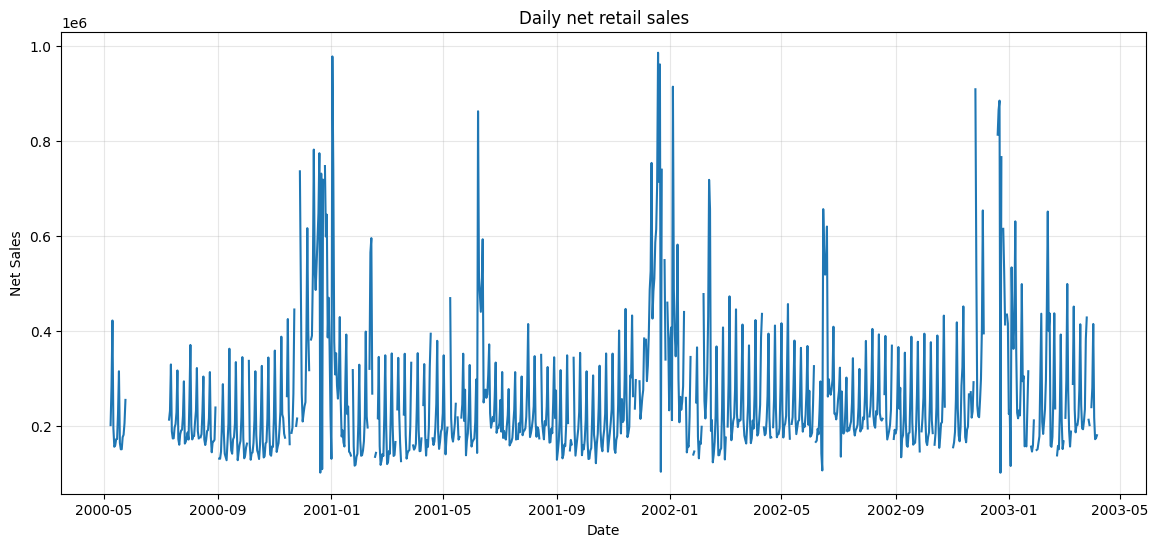

In [3]:
plt.figure(figsize=(14, 6))
plt.plot(data['sales'])
plt.title('Daily net retail sales')
plt.xlabel('Date')
plt.ylabel('Net Sales')
plt.grid(True, alpha=0.3)
plt.show()

Just from this plot, we can see that there appears to be a couple cyclical components that could be considered as seasonal. There seems to be a smaller pattern where sales go up and down periodically and there also seems to be some strong peaks at the end of the year and in both February and May approximately. We think that there might be both yearly and weekly seasonality. Trendwise, the overall trend of the data seems to stay constant, but because we only have 3 years of data we can't be sure that's the case. There is also a notable part of the data missing in the summer of 2000, which we can see in the plot. 

### Outliers

In [4]:
Q1 = data['sales'].quantile(0.25)
Q3 = data['sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers = data[(data['sales'] < lower_bound) | (data['sales'] > upper_bound)]

print(f"Number of outliers detected: {len(outliers)}")
print(f"Statistical Thresholds: Lower={lower_bound:.2f}, Upper={upper_bound:.2f}")

print("\n--- Outlier Dates and Values ---")
if not outliers.empty:
    print(outliers[['sales']])
else:
    print("No outliers detected using the 3 * IQR criterion.")

outlier_dates_list = outliers.index.strftime('%Y-%m-%d').tolist()

Number of outliers detected: 25
Statistical Thresholds: Lower=-187189.25, Upper=655022.75

--- Outlier Dates and Values ---
               sales
date                
2000-11-28  736537.0
2000-12-13  782376.0
2000-12-19  774691.0
2000-12-21  731735.0
2000-12-23  718611.0
2000-12-25  747641.0
2001-01-02  978742.0
2001-01-03  739943.0
2001-06-08  863155.0
2001-11-27  847603.0
2001-12-12  754260.0
2001-12-18  707410.0
2001-12-19  986587.0
2001-12-20  714213.0
2001-12-21  962011.0
2001-12-23  740004.0
2002-01-04  914987.0
2002-02-12  718537.0
2002-02-13  656895.0
2002-06-15  656832.0
2002-11-26  909531.0
2002-12-20  813748.0
2002-12-21  866111.0
2002-12-22  885587.0
2002-12-24  766510.0


We study the existence of extreme outliers, using the 3*IQR criterion to find them. There seems to be 25 of them and they are all part of those strong peaks we saw in the previous plot. We can't dismiss these as incorrect since they could potentially be real. We suppose that they are true values that happened during Black Friday and Christmas time sales, as well as some pre Valentine's Day sales in February and some start of summer shopping in the middle of June. Therefore, we decide to keep these, as they are real outliers and represent real variability in our data.
### Missing values


count       932.000000
mean     257741.883047
std      136753.269316
min      101105.000000
1%       119877.420000
25%      173758.750000
50%      211552.500000
75%      294074.750000
99%      804022.680000
max      986587.000000
Name: sales, dtype: float64
Number of missing values: 135
Percentage of missing values: 12.65%


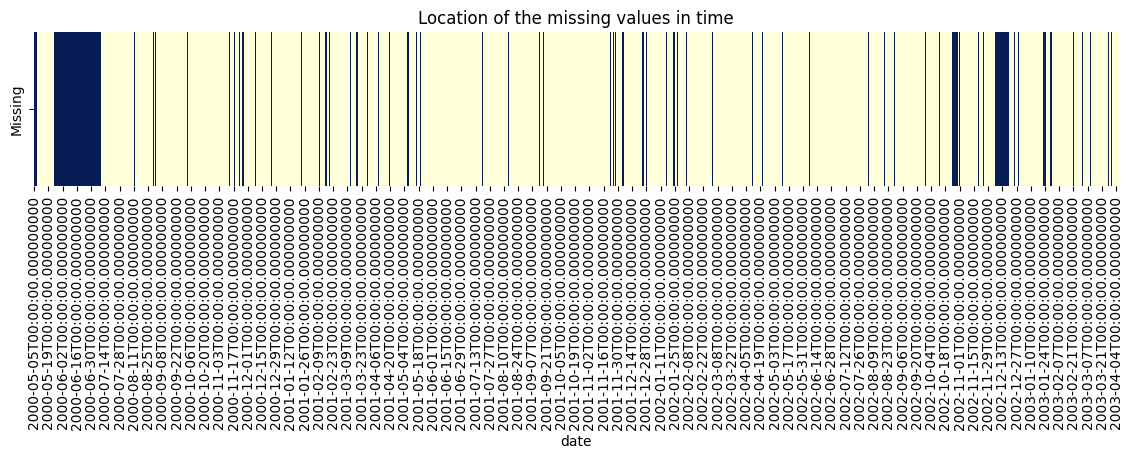

In [5]:
print(data['sales'].describe(percentiles=[.01, .25, .5, .75, .99]))

missing_total = data['sales'].isna().sum()
missing_pct = (missing_total / len(data)) * 100
print(f"Number of missing values: {missing_total}")
print(f"Percentage of missing values: {missing_pct:.2f}%")

plt.figure(figsize=(14, 2))
sns.heatmap(data[['sales']].isna().transpose(), cbar=False, cmap="YlGnBu", yticklabels=['Missing'])
plt.title("Location of the missing values in time")
plt.show()

Since there is such a big gap of missing data at the beginning of the time series, we decided to mark a new start for our data. This way, when we fill our missing data the results will be better, since we wouldn't be able to fill such a big gap in a realistic way that maintains true data distribution.

New start of the series: 2000-07-10 00:00:00
Missing values left: 86


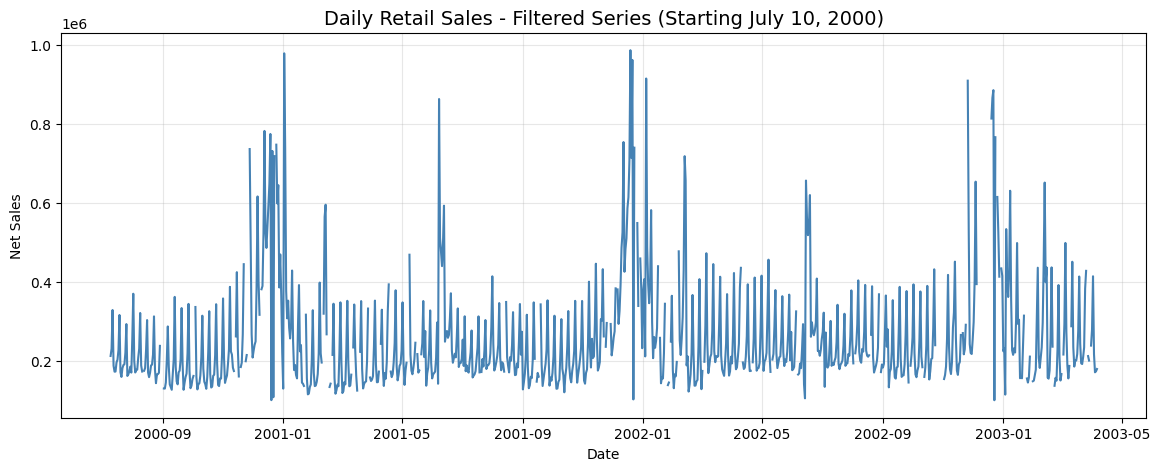

In [6]:
data_filtered = data[data.index >= '2000-07-10'].copy()

print(f"New start of the series: {data_filtered.index.min()}")
print(f"Missing values left: {data_filtered['sales'].isna().sum()}")

plt.figure(figsize=(14, 5))
plt.plot(data_filtered['sales'], color='steelblue')
plt.title('Daily Retail Sales - Filtered Series (Starting July 10, 2000)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Net Sales')
plt.grid(True, alpha=0.3)
plt.show()

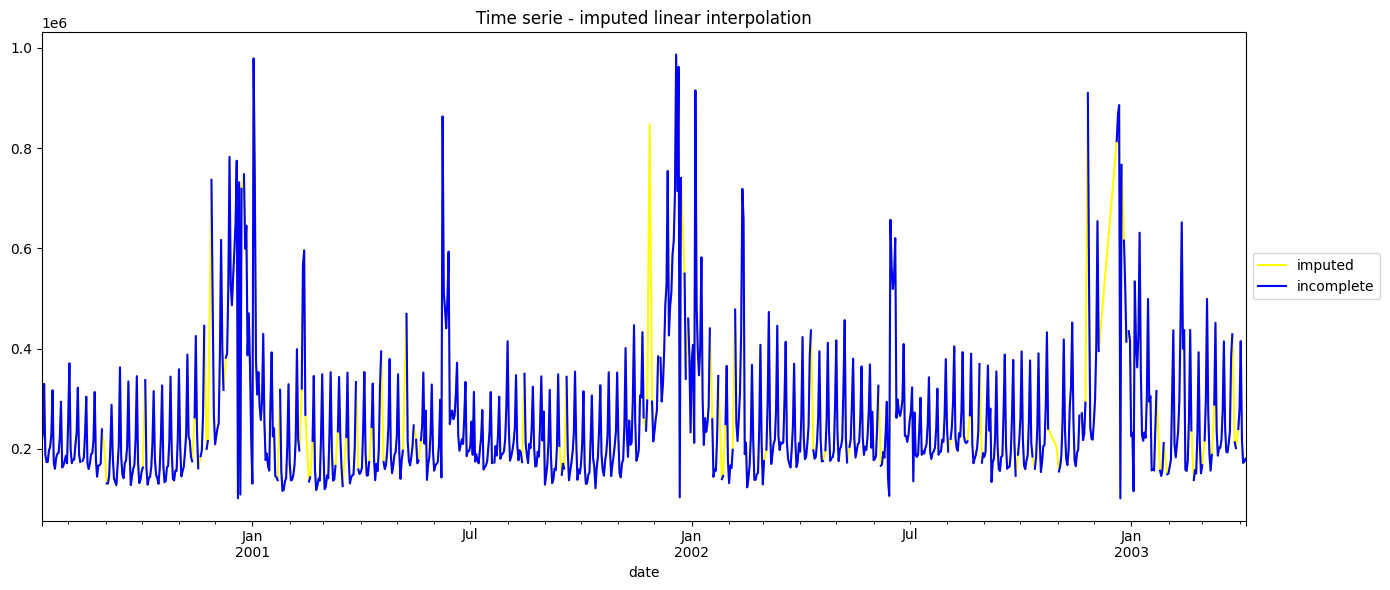

In [7]:
data_imputed = data_filtered.copy()
data_imputed['sales'] = data_imputed['sales'].interpolate(method="linear")
fig, ax = plt.subplots(figsize=(14, 6))

data_imputed['sales'].plot(ax=ax, label='imputed', color="yellow")
data_filtered['sales'].plot(ax=ax, label="incomplete", color="blue")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - imputed linear interpolation")
plt.tight_layout() 
plt.show()

We impute the data using the interpolation method, with the linear setting.
### Seasonality and cyclical trends


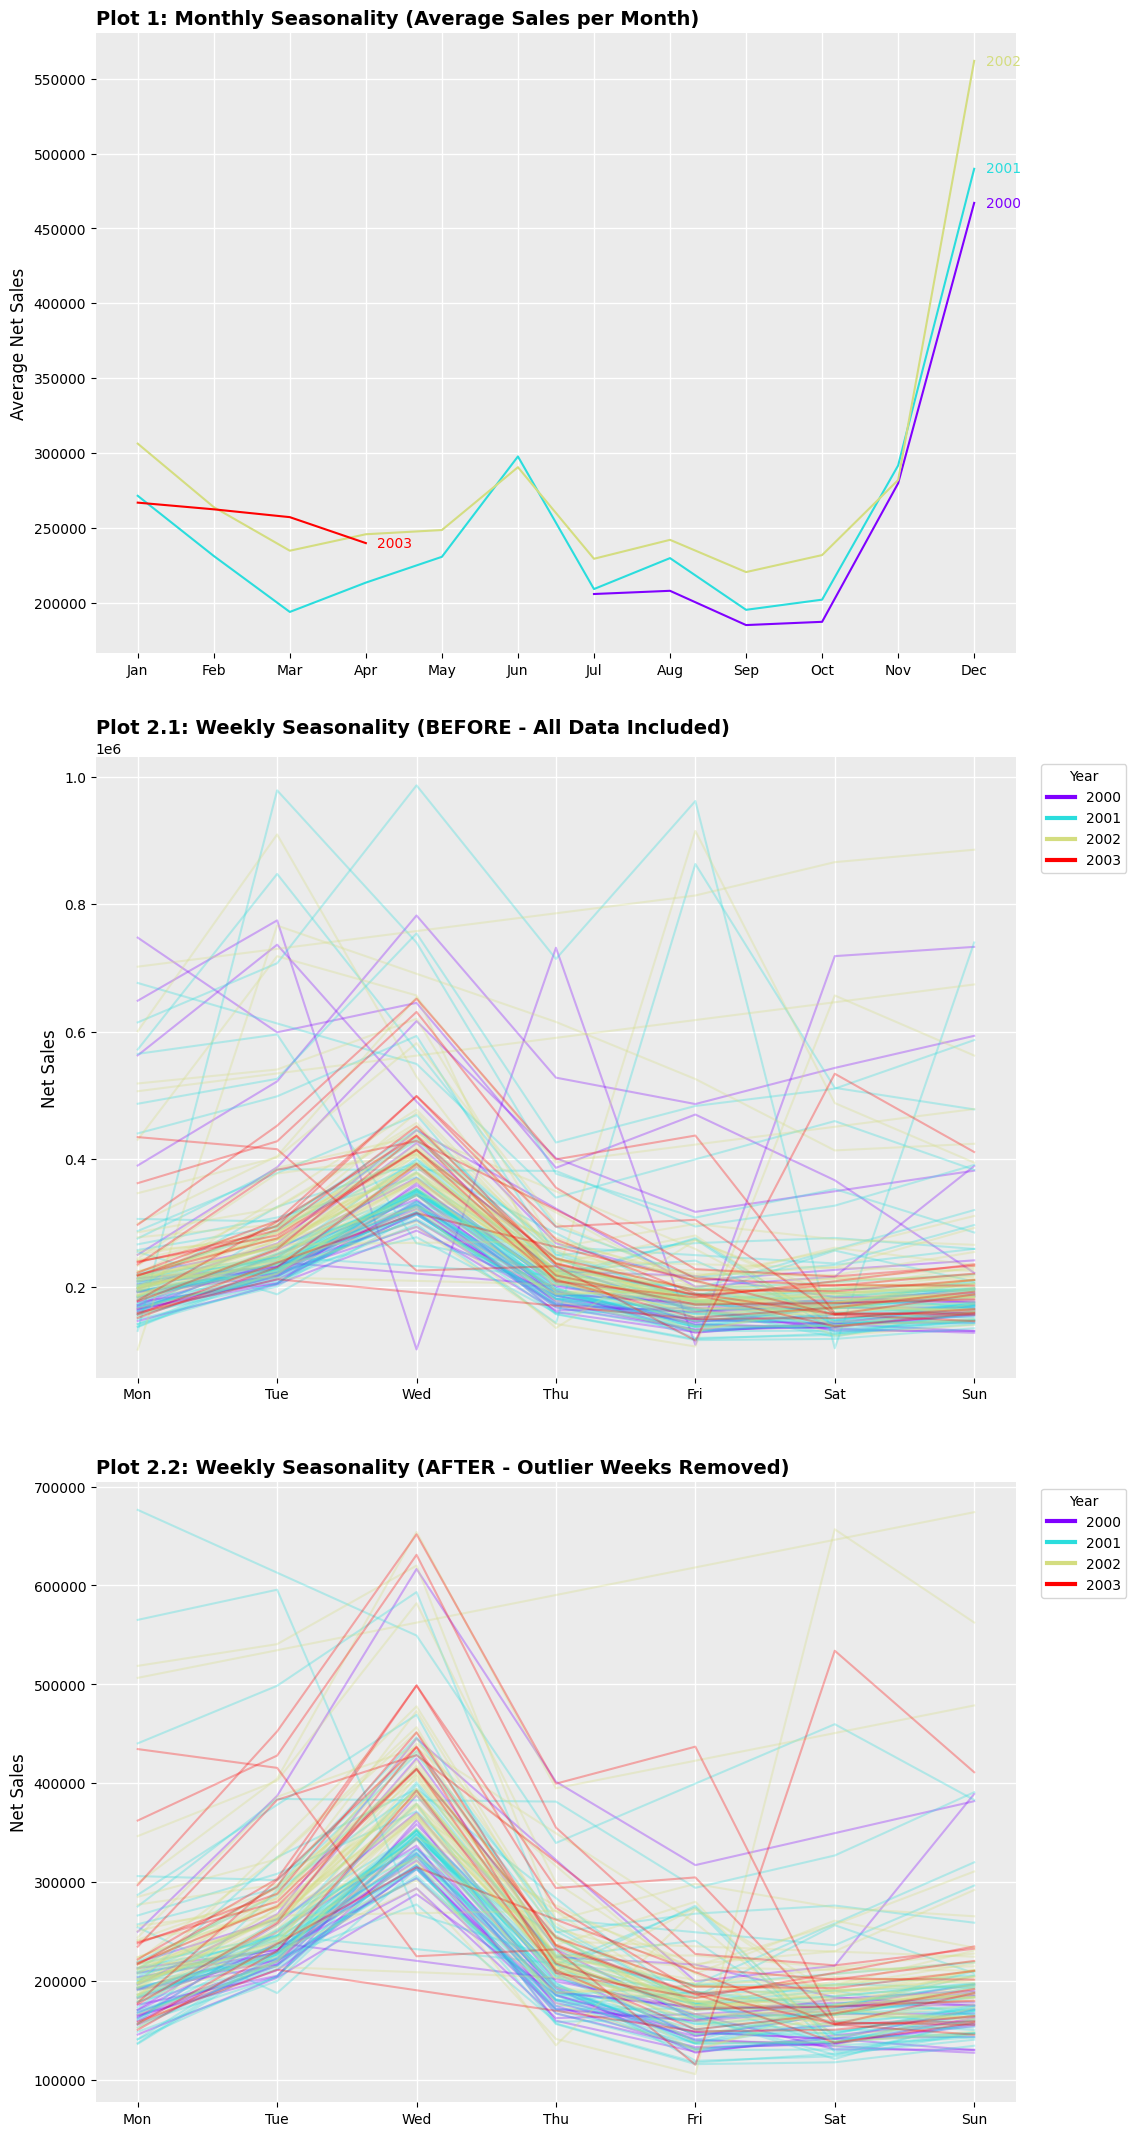

Total weeks originally: 143
Outlier weeks removed: 14
Total weeks plotted in 2.2: 129


In [8]:
import numpy as np
import calendar
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Make sure all our time components are ready
data_imputed['year'] = data_imputed.index.year
data_imputed['month'] = data_imputed.index.month
data_imputed['weekday'] = data_imputed.index.dayofweek
data_imputed['year_week'] = data_imputed.index.strftime('%G-%V') # Unique week ID

# Set up a 3-row figure to accommodate the before-and-after
fig, axes = plt.subplots(3, 1, figsize=(12, 22))
fig.patch.set_facecolor('white')

def style_axis(ax):
    ax.set_facecolor('#EBEBEB')
    ax.grid(True, color='white', linestyle='-', linewidth=1)
    for spine in ax.spines.values(): 
        spine.set_visible(False)

# ==========================================
# PLOT 1: Monthly Trends (Lines = Years)
# ==========================================
monthly_sales = data_imputed.groupby(['year', 'month'])['sales'].mean().reset_index()
pivot_monthly = monthly_sales.pivot(index='month', columns='year', values='sales')

ax1 = axes[0]
style_axis(ax1)

years_m = pivot_monthly.columns
cmap = plt.get_cmap('rainbow')
colors_m = [cmap(i) for i in np.linspace(0, 1, len(years_m))]

for i, year in enumerate(years_m):
    y_vals = pivot_monthly[year]
    ax1.plot(pivot_monthly.index, y_vals, color=colors_m[i], linewidth=1.5)
    
    last_idx = y_vals.last_valid_index()
    if pd.notna(last_idx):
        ax1.text(last_idx + 0.15, y_vals[last_idx], str(year), color=colors_m[i], va='center')

ax1.set_title('Plot 1: Monthly Seasonality (Average Sales per Month)', loc='left', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([calendar.month_abbr[i] for i in range(1, 13)])
ax1.set_ylabel('Average Net Sales', fontsize=12)

# ==========================================
# GLOBAL SETTINGS FOR WEEKLY PLOTS
# ==========================================
# Calculate a consistent color dictionary for all years
unique_years = sorted(data_imputed.index.year.unique())
denominator = len(unique_years) - 1 if len(unique_years) > 1 else 1
year_colors = {str(year): cmap(i / denominator) for i, year in enumerate(unique_years)}

# Create a shared legend handle
legend_elements = [mlines.Line2D([0], [0], color=year_colors[str(y)], lw=3, label=str(y)) 
                   for y in unique_years]

# ==========================================
# PLOT 2.1: Weekly Trends (BEFORE: With Outliers)
# ==========================================
pivot_weekly_all = data_imputed.pivot_table(index='weekday', columns='year_week', values='sales')

ax2 = axes[1]
style_axis(ax2)

for col in pivot_weekly_all.columns:
    y_vals = pivot_weekly_all[col]
    year_str = col.split('-')[0]
    color = year_colors.get(year_str, 'gray')
    ax2.plot(pivot_weekly_all.index, y_vals, color=color, linewidth=1.5, alpha=0.3)

ax2.legend(handles=legend_elements, title='Year', loc='upper left', bbox_to_anchor=(1.02, 1))
ax2.set_title('Plot 2.1: Weekly Seasonality (BEFORE - All Data Included)', loc='left', fontsize=14, fontweight='bold')
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax2.set_ylabel('Net Sales', fontsize=12)

# ==========================================
# PLOT 2.2: Weekly Trends (AFTER: Outlier Weeks Removed Entirely)
# ==========================================
# 1. Identify outliers using the 3*IQR rule
Q1 = data_imputed['sales'].quantile(0.25)
Q3 = data_imputed['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# 2. Find and drop the specific weeks that contain at least one outlier
outliers = data_imputed[(data_imputed['sales'] < lower_bound) | (data_imputed['sales'] > upper_bound)]
weeks_with_outliers = outliers['year_week'].unique()
df_filtered = data_imputed[~data_imputed['year_week'].isin(weeks_with_outliers)].copy()

# 3. Pivot the cleaned data
pivot_weekly_clean = df_filtered.pivot_table(index='weekday', columns='year_week', values='sales')

ax3 = axes[2]
style_axis(ax3)

for col in pivot_weekly_clean.columns:
    y_vals = pivot_weekly_clean[col]
    year_str = col.split('-')[0]
    color = year_colors.get(year_str, 'gray')
    ax3.plot(pivot_weekly_clean.index, y_vals, color=color, linewidth=1.5, alpha=0.3)

ax3.legend(handles=legend_elements, title='Year', loc='upper left', bbox_to_anchor=(1.02, 1))
ax3.set_title('Plot 2.2: Weekly Seasonality (AFTER - Outlier Weeks Removed)', loc='left', fontsize=14, fontweight='bold')
ax3.set_xticks(range(7))
ax3.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax3.set_ylabel('Net Sales', fontsize=12)

# Final layout adjustments
plt.tight_layout(pad=3.0)
plt.show()

# Print a quick summary of what was dropped
print(f"Total weeks originally: {len(pivot_weekly_all.columns)}")
print(f"Outlier weeks removed: {len(weeks_with_outliers)}")
print(f"Total weeks plotted in 2.2: {len(pivot_weekly_clean.columns)}")

We plot the data by years grouped by month and by day of the week. As we can see, the yearly cycles we saw in the original plot of the time series appear more clearly here. There's a clear peak around December, likely due to Black Friday and Christmas sales. Furthermore, there's a smaller peak in June, likely due to summer and holiday shopping. On the other hand, when we look at the weekly cycles, we can't see much at first, since there is quite some noise. But once we take out the outliers, we can see a clearer picture. The decision of taking out the outliers comes from the reason that it doesn't matter what day of the week, say, Black Friday is, there will be an increased number of sales nonetheless. So, to take this type of noise out of our plot, we take out the extreme outliers. Once we do that, we can see that there's a clear weekly cycle, where Wednesdays are the peak days for shopping. We suppose this is a typical sales phenomenon. 

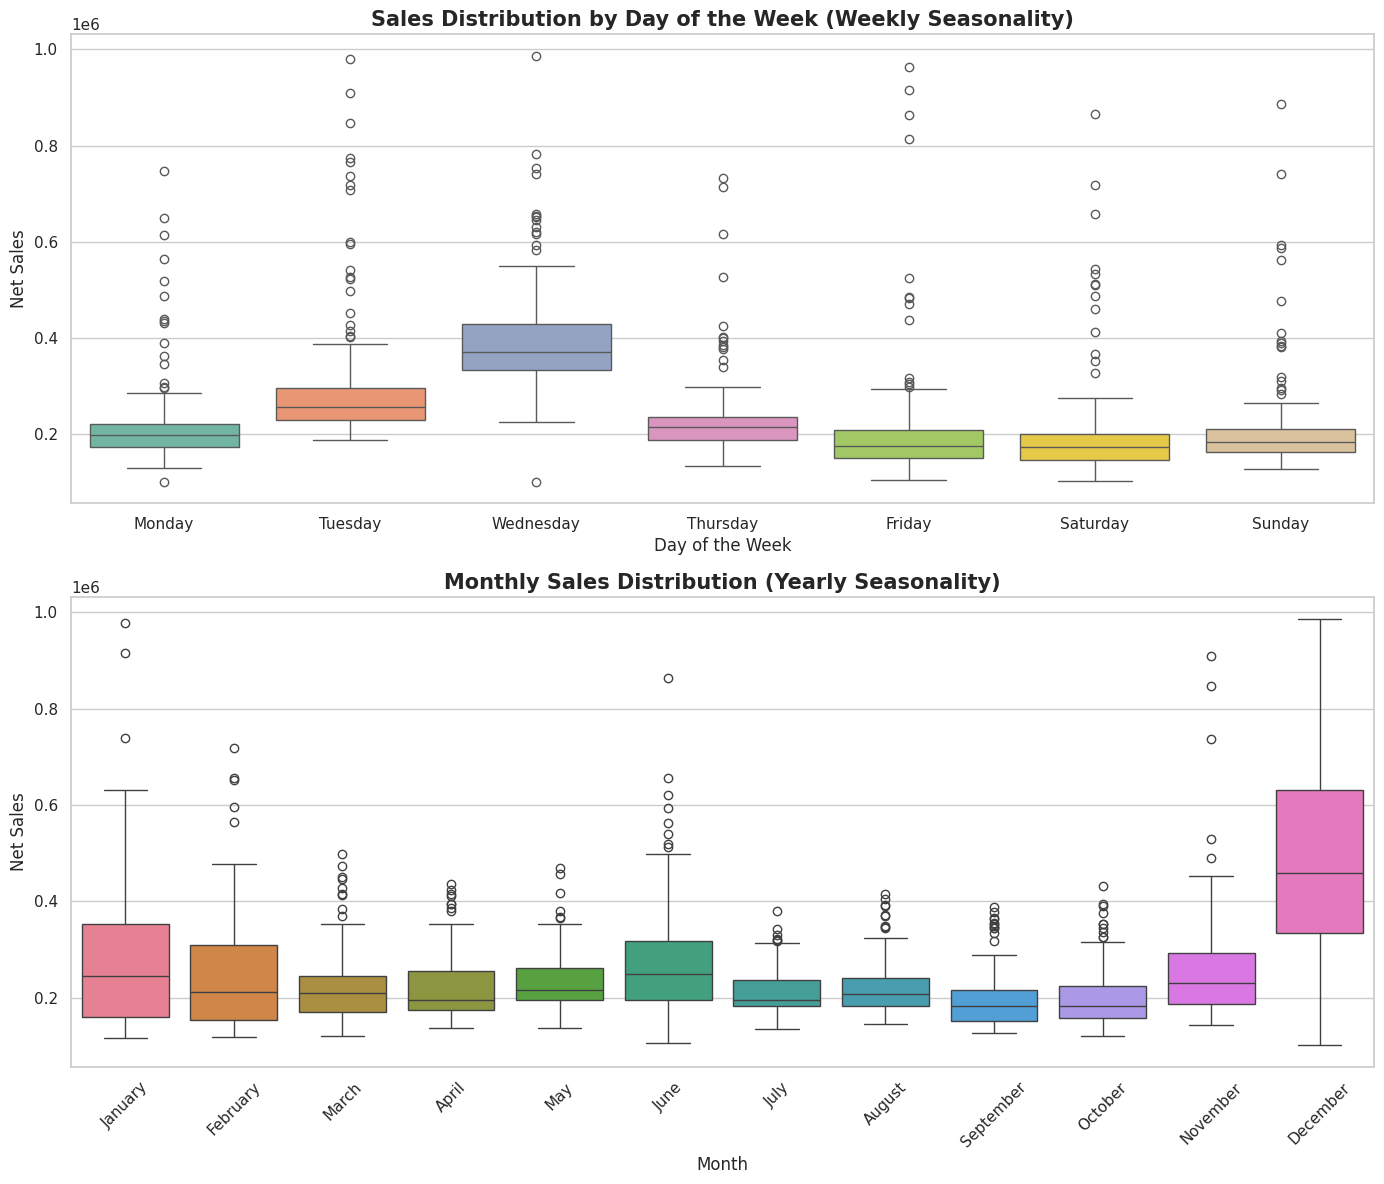

In [9]:
data_filtered['day_of_week'] = data_filtered.index.day_name()
data_filtered['month'] = data_filtered.index.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

data_filtered['day_of_week'] = pd.Categorical(data_filtered['day_of_week'], categories=day_order, ordered=True)
data_filtered['month'] = pd.Categorical(data_filtered['month'], categories=month_order, ordered=True)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.boxplot(data=data_filtered, x='day_of_week', y='sales', ax=axes[0], palette="Set2", hue='day_of_week', legend=False)
axes[0].set_title('Sales Distribution by Day of the Week (Weekly Seasonality)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Day of the Week', fontsize=12)
axes[0].set_ylabel('Net Sales', fontsize=12)

sns.boxplot(data=data_filtered, x='month', y='sales', ax=axes[1], palette="husl", hue='month', legend=False)
axes[1].set_title('Monthly Sales Distribution (Yearly Seasonality)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Net Sales', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Looking at the boxplots, we see something similar to what we've discussed before.

### STL Decomposition

=== WEEKLY SEASONALITY DECOMPOSITION ===


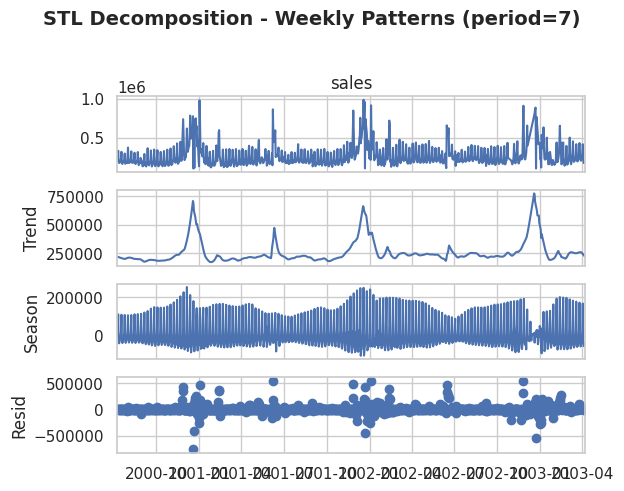

--- Numerical Results (Weekly Head) ---
Observed:
 date
2000-07-10    213038.0
2000-07-11    231461.0
2000-07-12    329375.0
2000-07-13    188393.0
2000-07-14    173321.0
Freq: D, Name: sales, dtype: float64
Trend:
 date
2000-07-10    220405.744399
2000-07-11    218886.945833
2000-07-12    217373.449190
2000-07-13    215882.310605
2000-07-14    214424.204191
Freq: D, Name: trend, dtype: float64
Seasonal:
 date
2000-07-10     -6189.806803
2000-07-11     14587.831857
2000-07-12    109426.655521
2000-07-13    -32709.435116
2000-07-14    -42255.641931
Freq: D, Name: season, dtype: float64
Remainder:
 date
2000-07-10   -1177.937596
2000-07-11   -2013.777690
2000-07-12    2574.895288
2000-07-13    5220.124512
2000-07-14    1152.437741
Freq: D, Name: resid, dtype: float64

--------------------------------------------------

=== YEARLY/MONTHLY SEASONALITY DECOMPOSITION ===


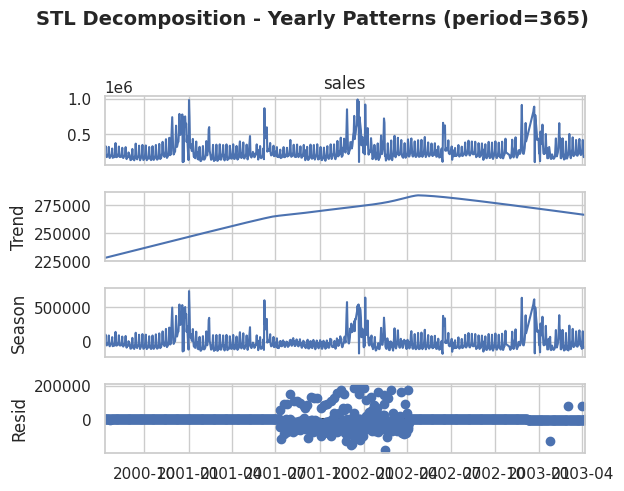

--- Numerical Results (Yearly Head) ---
Observed:
 date
2000-07-10    213038.0
2000-07-11    231461.0
2000-07-12    329375.0
2000-07-13    188393.0
2000-07-14    173321.0
Freq: D, Name: sales, dtype: float64
Trend:
 date
2000-07-10    227730.949948
2000-07-11    227839.895092
2000-07-12    227948.837559
2000-07-13    228057.777329
2000-07-14    228166.714381
Freq: D, Name: trend, dtype: float64
Seasonal:
 date
2000-07-10    -14535.938303
2000-07-11      3777.095018
2000-07-12    101581.128681
2000-07-13    -39510.837304
2000-07-14    -54692.802923
Freq: D, Name: season, dtype: float64
Remainder:
 date
2000-07-10   -157.011646
2000-07-11   -155.990110
2000-07-12   -154.966240
2000-07-13   -153.940025
2000-07-14   -152.911457
Freq: D, Name: resid, dtype: float64


In [10]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# =========================================================
# 1. WEEKLY SEASONALITY (Period = 7)
# =========================================================
print("=== WEEKLY SEASONALITY DECOMPOSITION ===")

# Initialize the STL model for weekly patterns (7 days).
stl_weekly = STL(data_imputed['sales'], period=7, robust=True)
res_weekly = stl_weekly.fit()

# Visualization
fig_weekly = res_weekly.plot()
plt.suptitle("STL Decomposition - Weekly Patterns (period=7)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Accessing numerical results
print("--- Numerical Results (Weekly Head) ---")
print('Observed:\n', res_weekly.observed.head())
print('Trend:\n', res_weekly.trend.head())
print('Seasonal:\n', res_weekly.seasonal.head())
print('Remainder:\n', res_weekly.resid.head())
print("\n" + "-"*50 + "\n")


# =========================================================
# 2. YEARLY SEASONALITY (Period = 365)
# =========================================================
print("=== YEARLY/MONTHLY SEASONALITY DECOMPOSITION ===")

# Initialize the STL model for yearly patterns (365 days).
# This will capture the larger macro-cycle, including your Jan/Jul discount spikes.
stl_yearly = STL(data_imputed['sales'], period=365, robust=True)
res_yearly = stl_yearly.fit()

# Visualization
fig_yearly = res_yearly.plot()
plt.suptitle("STL Decomposition - Yearly Patterns (period=365)", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Accessing numerical results
print("--- Numerical Results (Yearly Head) ---")
print('Observed:\n', res_yearly.observed.head())
print('Trend:\n', res_yearly.trend.head())
print('Seasonal:\n', res_yearly.seasonal.head())
print('Remainder:\n', res_yearly.resid.head())

Since we are dealing with two types of seasonality, none of these capture the data quite well. We would actually need a decomposition that combines both. We can't be totally sure of the trend of the time series, but it seems to be approximately constant overall, maybe it goes slightly up as time passes.

### Stationarity

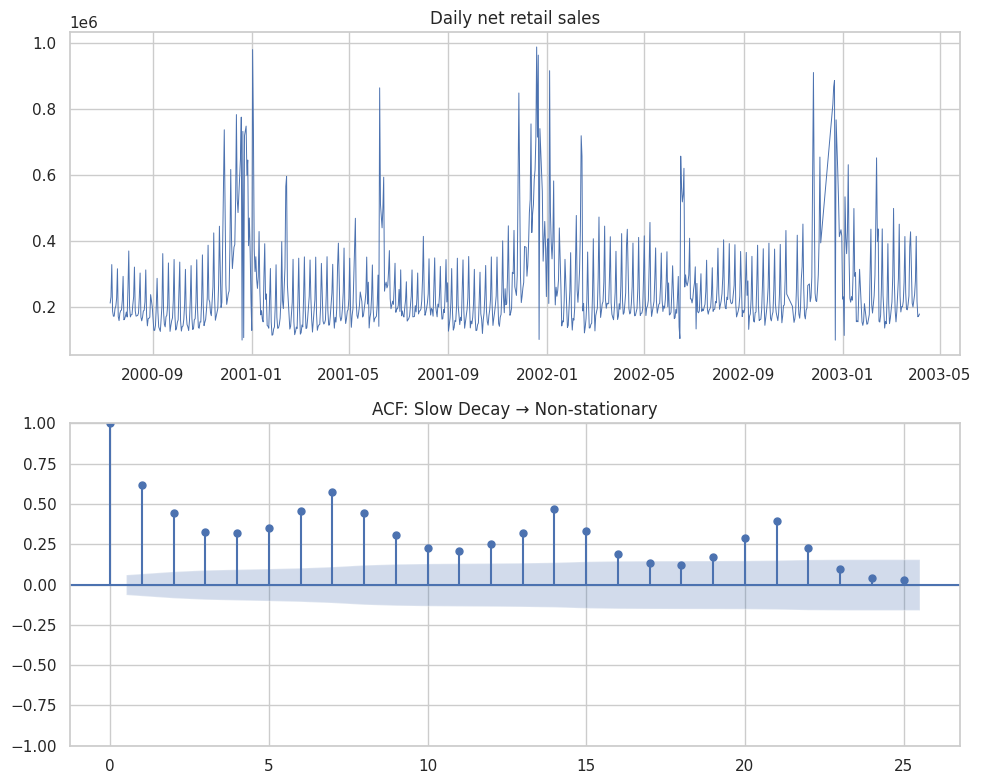

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(data_imputed['sales'], linewidth=0.7)
axes[0].set_title('Daily net retail sales')

plot_acf(data_imputed['sales'], lags=25, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF: Slow Decay → Non-stationary')

plt.tight_layout()
plt.show()

Since the ACF has a slow decay, we suppose that our series isn't stationary. We could have also inferred that looking at the plot of the time series and seeing that the variance of the series isn't constant through time, therefore breaking one of the conditions of weak stationarity.

In [12]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

result_adf = adfuller(data_imputed['sales'])

print(f"\n{'='*65}")
print(f"Augmented Dickey-Fuller Test: Retail Sales Series")
print('='*65)
print(f"ADF Statistic:          {result_adf[0]:.4f}")
print(f"P-value:                {result_adf[1]:.4f}")
print(f"Lags Used:              {result_adf[2]}")
print(f"Number of Observations: {result_adf[3]}")
print(f"Critical Values:")
for key, value in result_adf[4].items():
    print(f"   {key}: {value:.4f}")

if result_adf[1] <= 0.05:
    print("\nResult: Reject H0. The series is STATIONARY.")
else:
    print("\nResult: Fail to reject H0. The series is NON-STATIONARY.")


result_kpss = kpss(data_imputed['sales'], regression='c', nlags='auto')

print(f"\n{'='*65}")
print(f"KPSS Test: Retail Sales Series")
print('='*65)
print(f"KPSS Statistic:         {result_kpss[0]:.4f}")
print(f"P-value:                {result_kpss[1]:.4f}")
print(f"Lags Used:              {result_kpss[2]}")
print(f"Critical Values:")
for key, value in result_kpss[3].items():
    print(f"   {key}: {value:.4f}")

if result_kpss[1] <= 0.05:
    print("\nResult: Reject H0. The series is NON-STATIONARY.")
else:
    print("\nResult: Fail to reject H0. The series is STATIONARY.")


Augmented Dickey-Fuller Test: Retail Sales Series
ADF Statistic:          -4.4498
P-value:                0.0002
Lags Used:              22
Number of Observations: 978
Critical Values:
   1%: -3.4371
   5%: -2.8645
   10%: -2.5683

Result: Reject H0. The series is STATIONARY.

KPSS Test: Retail Sales Series
KPSS Statistic:         0.2713
P-value:                0.1000
Lags Used:              16
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390

Result: Fail to reject H0. The series is STATIONARY.


Looking at the results of the statistical tests, we see that both tests indicate that our time series is in fact stationary. Therefore, since these are more rigurous than the visual assesment, we take these results as conclusive. There is strong evidence of stationarity in our time series.

## 2. Data Preprocessing
Process the data as necessary based on your descriptive analysis. Justify why each
preprocessing step was chosen.

Missing value imputing through linear interpolation has already been done, as well as removing the initial part of the time series for having too many missing values.


Train dates : 2000-07-10 --- 2002-09-17  (n=800 days)
Test dates  : 2002-09-18 --- 2003-04-06  (n=201 days)


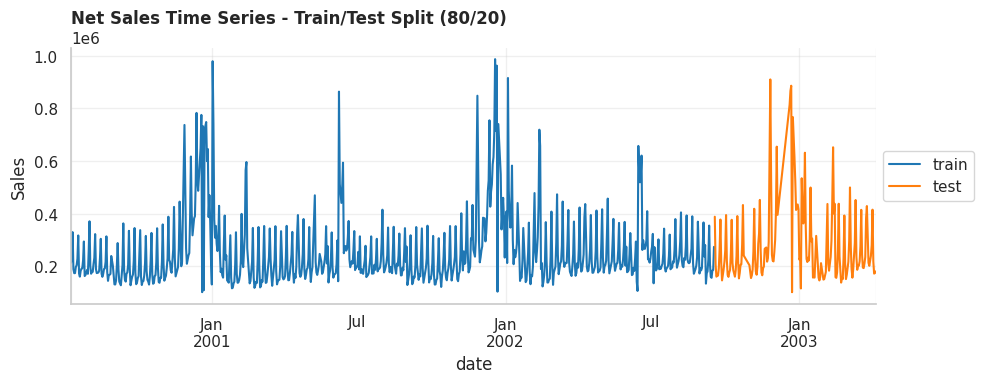

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Feature Engineering: Exogenous Month Variables (SARIMAX)
# ==============================================================================
# Create a dataframe for exogenous variables with the same index as your data
exog = pd.DataFrame(index=data_imputed.index)

# Create one-hot encoded dummies for months (using Feb-Dec to avoid the dummy variable trap)
for month in range(2, 13):
    exog[f'month_{month}'] = (data_imputed.index.month == month).astype(int)

# ==============================================================================
# 2. Train-Test Split (80/20)
# ==============================================================================
# Calculate the index for an 80/20 split
split_index = int(len(data_imputed) * 0.8)

# Split the main dataframe
data_train = data_imputed.iloc[:split_index]
data_test  = data_imputed.iloc[split_index:]

# Split the target variable (y)
y_train = data_train['sales']
y_test  = data_test['sales']

# Split the exogenous variables (exog)
exog_train = exog.iloc[:split_index]
exog_test  = exog.iloc[split_index:]

# ==============================================================================
# 3. Print Split Details
# ==============================================================================
print(
    f"Train dates : {data_train.index.min().date()} --- "
    f"{data_train.index.max().date()}  (n={len(y_train)} days)"
)
print(
    f"Test dates  : {data_test.index.min().date()} --- "
    f"{data_test.index.max().date()}  (n={len(y_test)} days)"
)

# ==============================================================================
# 4. Plot the Split
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 4)) 

y_train.plot(ax=ax, label='train', color='#1f77b4') # Blue
y_test.plot(ax=ax, label='test', color='#ff7f0e')  # Orange

# Formatting
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Net Sales Time Series - Train/Test Split (80/20)", loc='left', fontweight='bold')
ax.set_ylabel("Sales")
ax.grid(True, alpha=0.3)

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout() 
plt.show()

We create the training and test data splits for our models. We also create the exogenous variables that we'll be using in our model.

## 3. Model Selection and Fitting
Evaluate different statistical models (e.g., ARIMA, SARIMA, ARCH, GARCH) to
determine the best fit for your specific dataset. Outline your selection criteria and explain the rationale behind choosing your final model parameters over the alternatives.
### SARIMAX



**Rationale for Model Selection: Why SARIMAX?**
- ARIMA: Rejected. It cannot handle any seasonality.
- SARIMA: Rejected. While it can handle the weekly 7-day cycle, standard SARIMA cannot easily model multiple overlapping seasonalities (like our 7-day week plus our 365-day annual Jan/June spikes).
- SARIMAX (Selected): This is the perfect fit to be able to input both of our observed cycles into the model. We will use the Seasonal component of the model to learn the 7-day weekly cycle (m=7). Then, we will use the Exogenous (X) component to feed the model "dummy variables" for the months of the year, allowing it to explicitly learn and predict the massive December and June sales spikes.

For parameter selection (p, q, P, Q), we will use pmdarima.auto_arima optimizing for the lowest AIC (Akaike Information Criterion), which balances model accuracy with simplicity to prevent overfitting.

But first, to provide a comprehensive analysis of our retail sales data, we use the Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots to visually identify the necessary model parameters before automated fitting.

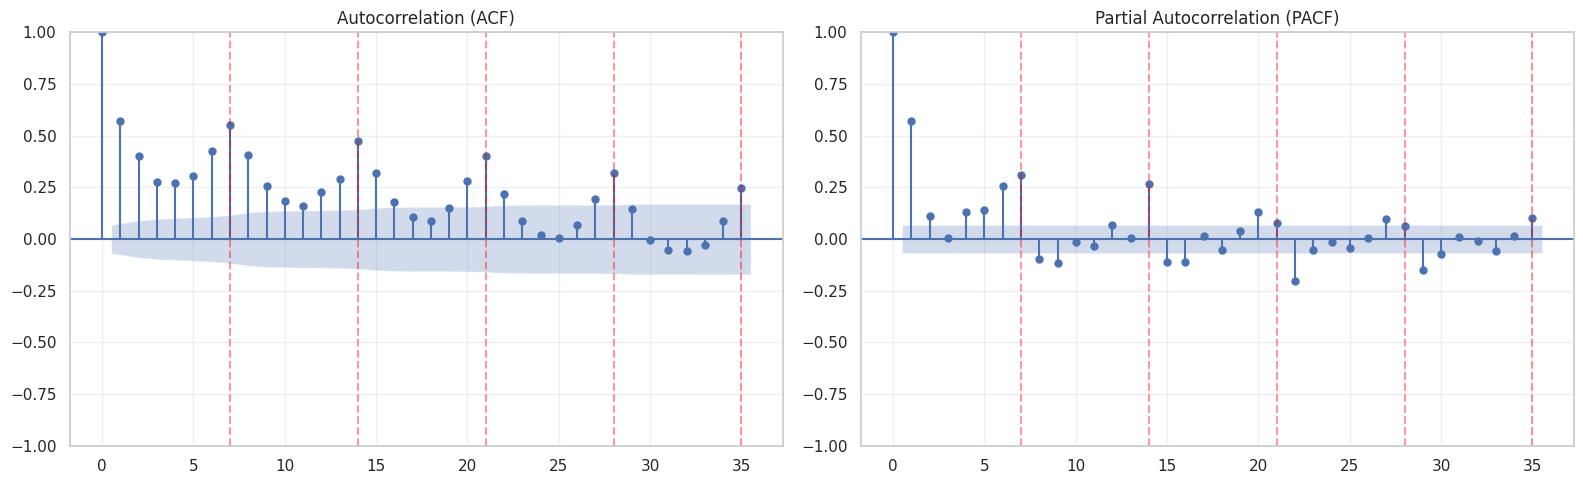

In [14]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==============================================================================
# 0. Visual Parameter Identification (ACF & PACF)
# ==============================================================================
# We use 35 lags to see at least 5 full weeks of seasonality (7 * 5 = 35)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF: Good for identifying the Moving Average (q) and Seasonal MA (Q) terms
# Slow decay in ACF usually suggests non-stationarity, but your tests already cleared this.
plot_acf(y_train, ax=axes[0], lags=35, alpha=0.05, title='Autocorrelation (ACF)')
axes[0].grid(True, alpha=0.3)

# Plot PACF: Good for identifying the Auto-Regressive (p) and Seasonal AR (P) terms
plot_pacf(y_train, ax=axes[1], lags=35, alpha=0.05, title='Partial Autocorrelation (PACF)', method='ywm')
axes[1].grid(True, alpha=0.3)

# Highlight seasonal lags (multiples of 7) to make them easier to spot
for ax in axes:
    for lag in [7, 14, 21, 28, 35]:
        ax.axvline(x=lag, color='red', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

We conduct a visual identification to estimate potential autoregressive ($p$) and moving average ($q$) orders. For daily data, we examine lags in groups of 7 to account for the weekly cycle.

**Key Observations from the Plots:**
- Non-Seasonal Identification ($p, q$):
    - PACF: Significant spikes are observed at lags 1 and 2, suggesting a second-order autoregressive process ($p=2$).
    - ACF: A significant spike at lag 1 suggests a first-order moving average process ($q=1$).
- Seasonal Identification ($P, Q, s$):
    - The red dashed lines highlight the weekly seasonal lags (7, 14, 21, 28, 35).
    - Significant spikes at lags 7 and 14 in both the ACF and PACF justify the inclusion of seasonal components. Specifically, the decay patterns suggest a seasonal order of at least $(2, 0, 1)_7$.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_absolute_error

# ==============================================================================
# 1. Model Selection and Fitting (Auto-ARIMA)
# ==============================================================================
print("\nRunning Auto-ARIMA to find the best SARIMAX parameters...")
print("Optimizing for lowest AIC. This may take a few minutes...\n")

model_auto = pm.auto_arima(
    y=y_train,
    X=exog_train,            # Passing our month dummies
    seasonal=True, m=7,      # Explicitly modeling the 7-day weekly cycle
    d=0,                     # Set to 0 because our ADF/KPSS tests proved stationarity
    D=None,                  # Let the model test if seasonal differencing is needed
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    information_criterion='aic',
    trace=True,              # Prints progress
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True            # Uses efficient search algorithm
)

print("\n" + "="*60)
print(f"Best Model Selected: SARIMAX {model_auto.order} x {model_auto.seasonal_order}")
print("="*60)


Running Auto-ARIMA to find the best SARIMAX parameters...
Optimizing for lowest AIC. This may take a few minutes...

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=21220.202, Time=0.12 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=20832.360, Time=0.90 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=20953.397, Time=0.61 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=25787.977, Time=0.14 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=20918.855, Time=0.10 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=20764.103, Time=2.00 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=20738.581, Time=1.35 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=20761.508, Time=1.27 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=4.17 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=20743.513, Time=1.47 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AIC=21039.233, Time=1.14 sec
 ARIMA(2,0,0)(2,0,1)[7] intercept   : AIC=20725.844, Time=1.54 sec
 ARIMA(2,0,0)(1,0,1)[7] intercept   : AIC

**Final Model Selection and Rationale**

After evaluating candidate models, the automated grid-search algorithm selected **SARIMAX (2, 0, 1) x (2, 0, 1, 7) with an intercept** as the best fit for our net sales dataset. 

**Selection Criteria:**
The primary selection criterion used to evaluate the alternatives was the **Akaike Information Criterion (AIC)**. AIC is a mathematical method for evaluating how well a model fits the data it was generated from. It heavily penalizes adding unnecessary parameters, which protects the model from overfitting. Our goal was to find the parameter combination that minimized the AIC score.

**Rationale for Final Parameters:**
The stepwise search evaluated 30 different parameter combinations. 
1. **The Baseline:** A completely naive model with no autoregressive or moving average terms `ARIMA(0,0,0)(0,0,0)[7]` yielded a very high AIC of 21220.20.
2. **Finding the Sweet Spot:** By incorporating recent historical lags and weekly seasonal lags, the AIC dropped significantly. The final chosen model `ARIMA(2,0,1)(2,0,1)[7]` achieved the lowest valid score of **20714.08**. 
3. **Rejecting Over-Complexity:** We can see the algorithm actively rejected overly complex alternatives. For example, adding more parameters, such as `ARIMA(2,0,1)(2,0,2)[7]` or `ARIMA(3,0,1)(2,0,1)[7]`, resulted in `AIC=inf`. This indicates that the model either failed to converge or the complexity penalty outweighed any marginal gain in accuracy.
4. **Enforcing and Verifying Stationarity (d=0, D=0):** Because our manual ADF and KPSS tests confirmed the original series was already stationary, we explicitly forced the non-seasonal differencing parameter to zero (`d=0`) to prevent over-differencing. For the seasonal component, we allowed the algorithm to test for stationarity (`D=None`). The algorithm's internal tests verified that seasonal differencing was also unnecessary, locking in `D=0` for all evaluated models.

In business terms, this model rationally predicts today's net sales by looking at the momentum of the last two days (p=2), adjusting for yesterday's forecasting error (q=1), and anchoring the expectation to how the business performed on this exact day of the week over the last two weeks (P=2, Q=1).

## 4. Model Validation and Predictive Quality
Perform diagnostic checks on the model to ensure the model's assumptions are met. Evaluate the forecasting performance of your model using appropriate metrics and validation scheme.

In this section, we validate the SARIMAX model. Validation is divided into two phases: **Residual Diagnostics**, to ensure the model has extracted all available information, and **Predictive Evaluation**, where we compare our hybrid forecast against actual data using standard metrics.

### Diagnostic Checks: Validating Assumptions
For a time series model to be considered valid, its residuals (errors) should ideally behave as White Noise: normally distributed, centered at zero, and showing no significant autocorrelation.

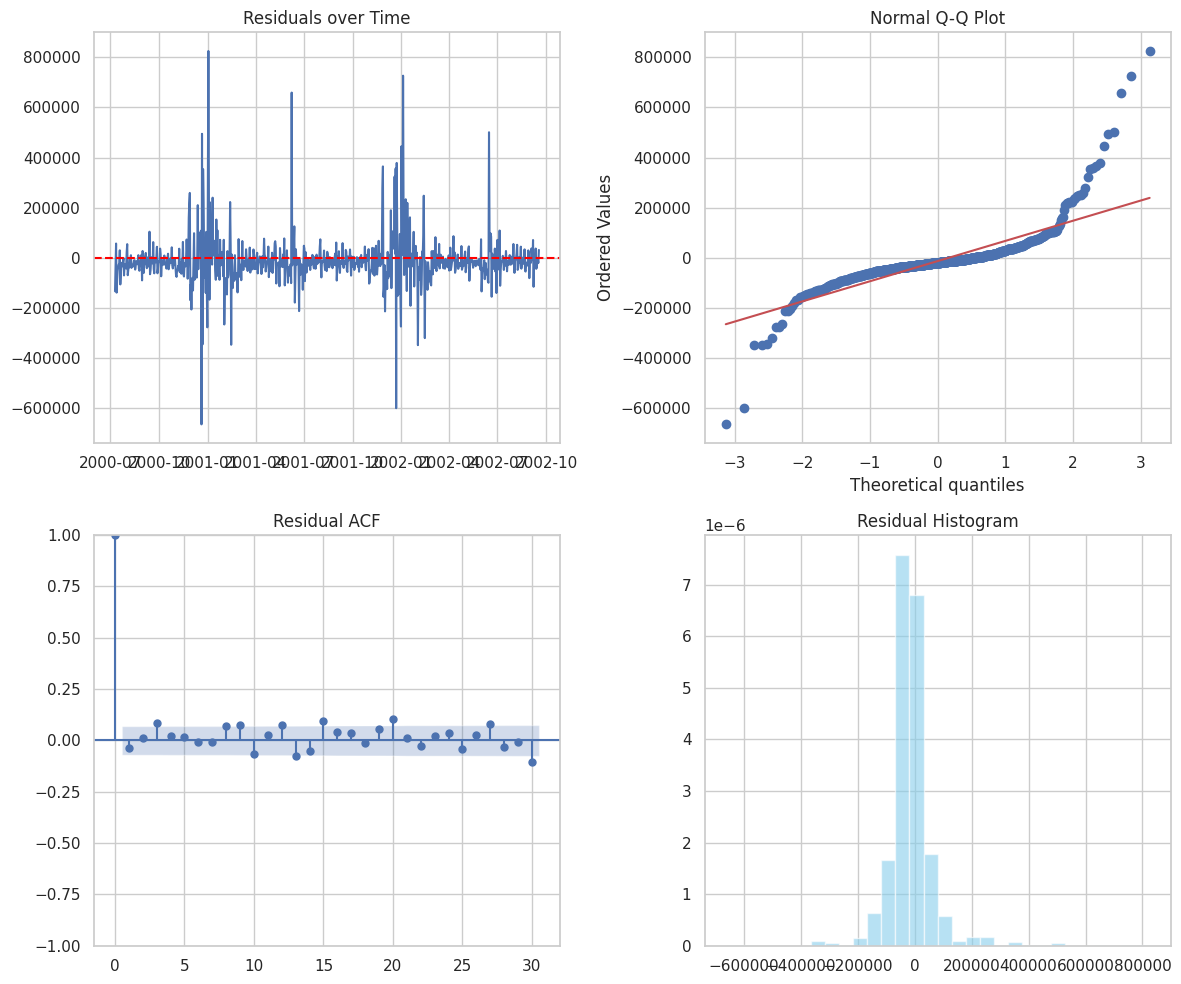

Ljung-Box Test (Independence) p-value: 0.0036


In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Obtain Residuals from the SARIMAX model
res = model_auto.resid()

# 2. Visual Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Time Plot: Residuals should look like random noise around zero
axes[0, 0].plot(res)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title("Residuals over Time")

# Q-Q Plot: Points should follow the 45-degree line for normality
stats.probplot(res, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q Plot")

# ACF: Spikes should stay within the blue significance band
plot_acf(res, ax=axes[1, 0], lags=30)
axes[1, 0].set_title("Residual ACF")

# Histogram: Should show a bell-shaped (Normal) curve
axes[1, 1].hist(res, bins=30, density=True, alpha=0.6, color='skyblue')
axes[1, 1].set_title("Residual Histogram")

plt.tight_layout()
plt.show()

# 3. Formal Statistical Tests
lb_test = acorr_ljungbox(res, lags=[14], return_df=True)
print(f"Ljung-Box Test (Independence) p-value: {lb_test['lb_pvalue'].values[0]:.4f}")
# If p > 0.05, residuals are independent (White Noise)

**Analysis of Results**
While our previous visual identification and model selection led to the SARIMAX(2,0,1)x(2,0,1,7) specification, we must evaluate if the residuals behave as white noise.

Visual Residual Analysis:
- Residuals over Time: The plot shows clear "bursts" of volatility, particularly around January and July. This confirms that the SARIMAX model alone cannot handle both seasonalities that are apparent in the data, even if we tried to input both using exogenous variables.
- Normal Q-Q Plot: The points deviate significantly from the red 45-degree line at both tails. This indicates that the residuals have "heavy tails", meaning extreme sales shocks happen more often than a standard normal distribution would predict.
- Residual ACF: Almost all spikes stay within the blue significance band, suggesting that the SARIMAX model has successfully captured the majority of the linear time-dependency and seasonality.
- Residual Histogram: While centered at zero, the distribution is very narrow and tall with long outliers, reinforcing the "heavy-tailed" nature of the retail sales errors.

Formal Statistical Tests:
- Ljung-Box Test (Independence): The p-value is 0.0036. Since this is below the 0.05 threshold, we reject the null hypothesis of independence. This indicates there is still some remaining autocorrelation in the residuals that the SARIMAX model did not fully capture.

### Forecasting Performance: SARIMAX
We now generate the final out-of-sample forecast. In this approach, we utilize the SARIMAX model to produce the point forecast and the associated prediction intervals. The intervals are calculated based on the standard error of the model's residuals, providing a consistent margin of error across the forecast horizon.

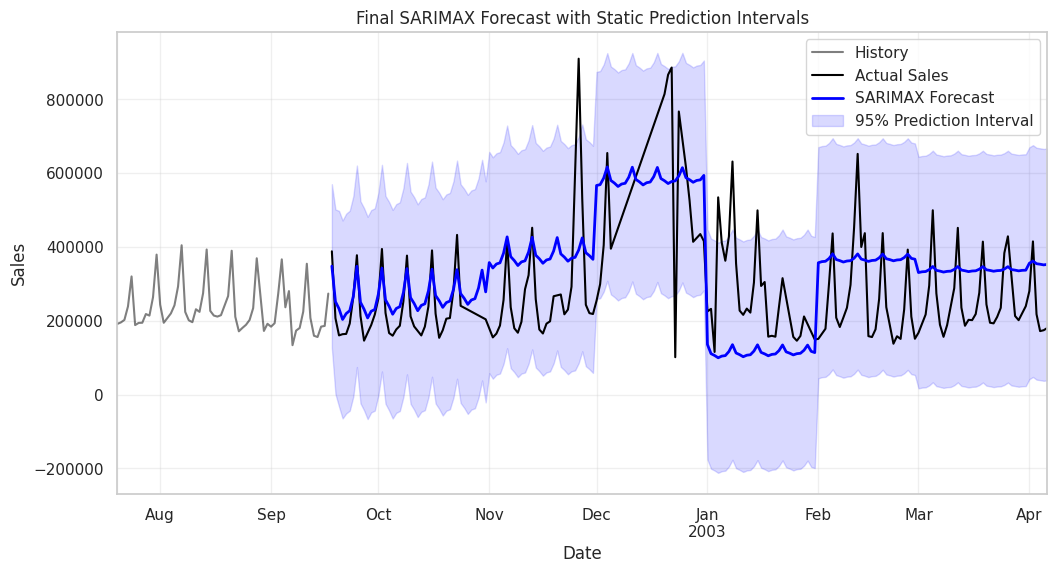

In [17]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Generate SARIMAX Point Forecast and Confidence Intervals
# We pass the future exogenous month variables (exog_test) for the test period.
# alpha=0.05 specifies a 95% confidence level.
steps = len(y_test)
forecast_series, conf_int = model_auto.predict(
    n_periods=steps, 
    X=exog_test, 
    return_conf_int=True, 
    alpha=0.05
)

# 2. Extract the lower and upper bounds
lower_bound = conf_int[:, 0]
upper_bound = conf_int[:, 1]

# 3. Visualization
plt.figure(figsize=(12, 6))

# Plot historical context (last 60 days) and actual test data
y_train.iloc[-60:].plot(label='History', color='black', alpha=0.5)
y_test.plot(label='Actual Sales', color='black', linewidth=1.5)

# Plot SARIMAX Point Forecast
forecast_series.plot(label='SARIMAX Forecast', color='blue', linewidth=2)

# Plot the SARIMAX Prediction Intervals (95% PI)
plt.fill_between(
    y_test.index, 
    lower_bound, 
    upper_bound, 
    color='blue', 
    alpha=0.15, 
    label='95% Prediction Interval'
)

plt.title("Final SARIMAX Forecast with Static Prediction Intervals")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Visual Analysis of the SARIMAX Forecast**
- Point Forecast (Mean Component): The blue line successfully tracks the fundamental structural patterns of the series, capturing both high-frequency weekly oscillations (weekend spikes) and the deterministic shifts driven by monthly exogenous variables. This is particularly evident in the jump in baseline sales starting in February 2003.
- Static Prediction Intervals: The light blue shaded area represents the 95% Prediction Interval (PI). In this final model, these bands remain uniform in width across the forecast horizon, reflecting the model's assumption of constant variance (homoscedasticity).
- Standardized Uncertainty: These intervals provide a consistent baseline for the expected range of sales. While they do not expand during high-volume periods, they offer a clear, parsimonious view of model uncertainty for general inventory planning.

Actual vs. Forecast Performance:
- Seasonal Envelope: The model tracks the seasonal "envelope" of the retail data with high accuracy, effectively capturing the core trend and repeating cycles.
- Outlier Handling: Several extreme daily spikes—specifically the massive peaks in late November and late December—fall significantly outside the 95% interval. This reinforces the diagnostic finding that residuals are "heavy-tailed", indicating that real-world retail shocks in this dataset are more extreme than the model’s standard normal assumption anticipates.

### Quantitative Evaluation: Predictive Quality
We use several metrics to evaluate how well the model performed on the held-out test set. MAE measures the average magnitude of errors, while MAPE provides the error as a percentage of the actual sales.

In [18]:
# Calculate Metrics
mae_val = mean_absolute_error(y_test, forecast_series)
rmse_val = np.sqrt(mean_squared_error(y_test, forecast_series))
mape_val = np.mean(np.abs((y_test - forecast_series) / y_test)) * 100

# Display results in a clean table
performance_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)'],
    'Value': [mae_val, rmse_val, mape_val]
}).round(2)

print("\n" + "="*40)
print("FINAL PREDICTIVE PERFORMANCE")
print("="*40)
print(performance_results.to_string(index=False))


FINAL PREDICTIVE PERFORMANCE
  Metric     Value
     MAE 121216.66
    RMSE 149493.84
MAPE (%)     49.13


**Performance Interpretation**

* **Error Magnitude (MAE & RMSE):** The **MAE** indicates that, on average, the model's sales forecasts deviate by approximately **121,217 units** from the actual values. The **RMSE** is notably higher at **149,494 units**. Since RMSE penalizes larger errors more heavily than MAE, the gap between these two metrics confirms that the model struggles to predict extreme daily spikes (outliers). This aligns with the visual evidence found in the **Residual Diagnostics** and the **Normal Q-Q Plot**, which displayed significant deviations at the tails.

* **Percentage Error (MAPE):** A **MAPE of 49.13%** indicates a significant average deviation relative to the actual sales volume. It reflects the inherent difficulty of predicting precise daily volumes in high-volatility retail environments with extreme seasonality. The presence of "heavy-tailed" shock events, particularly during the December and January peaks shown in the forecast plot, contributes to this percentage error.

* **Model Utility:** Despite the reported error metrics, the visual analysis demonstrates that the model successfully captures the **weekly cycle** and the broader **monthly trends**. The SARIMAX model provides a reliable structural baseline, even though the stochastic noise and extreme outliers in the data lead to a higher overall error magnitude.

## 5. Conclusions